# Ejemplos de probabilidad
Y aprovechamos a aplicar lo visto en paquetes

In [1]:
# Importar paquetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para las distribuciones
from scipy import stats

## ¿Qué usaremos de librerías?

In [2]:
# Arrays de numpy

a = np.array([1, 2, 3, 4, 5])
print("Array:", a)
print("Media:", a.mean())
print("Desvío estándar:", a.std())

# Operaciones vectorizadas (sin loops)
print("Cuadrado de cada elemento:", a ** 2)

# Rango de valores
x = np.linspace(0, 10, 5)   # 5 valores entre 0 y 10
print("linspace:", x)

Array: [1 2 3 4 5]
Media: 3.0
Desvío estándar: 1.4142135623730951
Cuadrado de cada elemento: [ 1  4  9 16 25]
linspace: [ 0.   2.5  5.   7.5 10. ]


Podemos generar eventos aleatorios.
Para cualquier fenómeno aleatorio necesitaremos una semilla (y tambien para que sea reproducible)


In [4]:
# Set de semilla
np.random.seed(42)

---
### Experimento de tirada de dado

In [5]:
# Generar números aleatorios
# Simular tiradas de dados
tiradas = 10

dado = np.random.randint(1, 7, size=tiradas)
print("Tiradas:", dado)
print("Frecuencia relativa de cada cara:")
caras, conteos = np.unique(dado, return_counts=True)
for cara, conteo in zip(caras, conteos):
    print(f"  Cara {cara}: {conteo/len(dado):.2f}")

Tiradas: [4 5 3 5 5 2 3 3 3 5]
Frecuencia relativa de cada cara:
  Cara 2: 0.10
  Cara 3: 0.40
  Cara 4: 0.10
  Cara 5: 0.40


In [6]:
sum(conteos)

np.int64(10)

Hagamos un gráfico con matplotlib

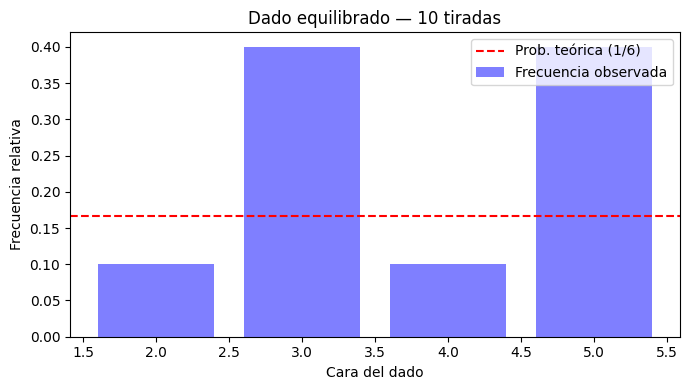

In [7]:
# Gráfico con fig,ax
fig, ax = plt.subplots(figsize=(7, 4))

# Ploteamos como barras la frecuencia observada
ax.bar(caras, conteos/tiradas, color='blue', alpha=0.5, label='Frecuencia observada')
ax.axhline(1/6, color='red', linestyle='--', linewidth=1.5, label='Prob. teórica (1/6)')

ax.set_xlabel('Cara del dado')
ax.set_ylabel('Frecuencia relativa')
ax.set_title(f'Dado equilibrado — {tiradas} tiradas')
ax.legend()
plt.tight_layout()
plt.show()

---
## Distribuciones Discretas

Ejemplifiquemos cada una de las distribuciones, viendo en cada caso:
1. Cómo calcular las probabilidades con `scipy.stats`.
2. Cómo simular muestras con `numpy`.
3. El efecto de los parámetros en la forma.

### Binomial — $X \sim \text{Bi}(n, p)$

Cantidad de éxitos en $n$ ensayos independientes, cada uno con probabilidad de éxito $p$.

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

> **Ejemplo:** ¿Cuántos estudiantes aprueban una materia en un grupo de 30, si cada uno tiene 60% de probabilidad de aprobar?

In [21]:
#Defino los parámetros de la binomial
n, p = 30, 0.6
#Creo el vector de alumnos para graficar la distribucion (la entrada en la función es entendida como la cantidad de exitos)
k = np.arange(0, n + 1)


![Binomial](../img/prob_estadistica/binomial.png)

In [22]:

# Probabilidades exactas con scipy
probs = stats.binom.pmf(k, n, p) #Esta es la distribución y devuelve la probabilidad para cada valor de k (exitos)
acumulada = stats.binom.cdf(k, n, p)

# Simular 1000 grupos y guardar en DataFrame
simulacion = np.random.binomial(n, p, size=1000)
df_binom = pd.DataFrame({'aprobados': simulacion})
print(df_binom['aprobados'].describe().round(2))

count    1000.00
mean       17.94
std         2.73
min         9.00
25%        16.00
50%        18.00
75%        20.00
max        25.00
Name: aprobados, dtype: float64


In [23]:
df_binom

,aprobados
0,20
1,18
2,20
3,12
4,14
...,...
995,20
996,20
997,16
998,18


In [24]:
print(probs.sum())
print(acumulada.max())

1.000000000000001
1.0


In [30]:
print(probs[17])

0.13603867307600329


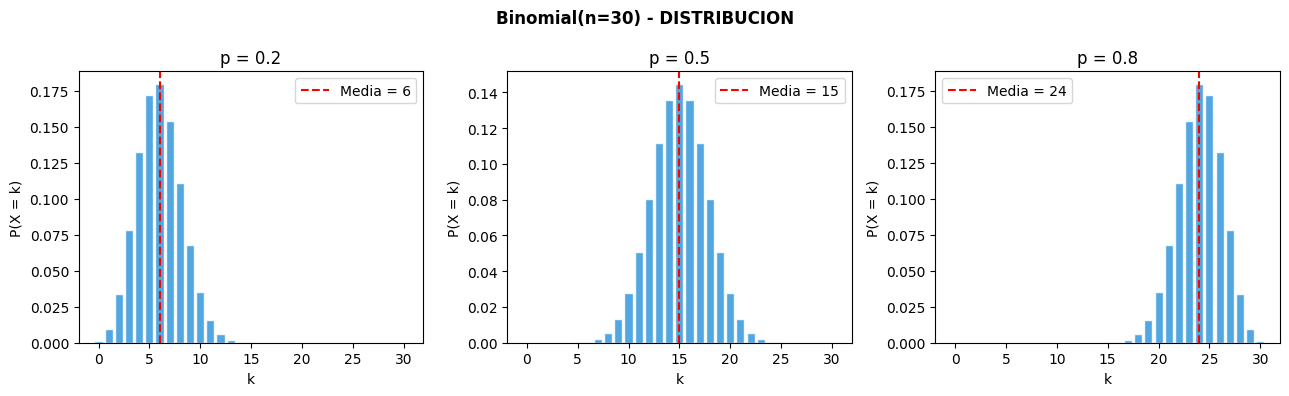

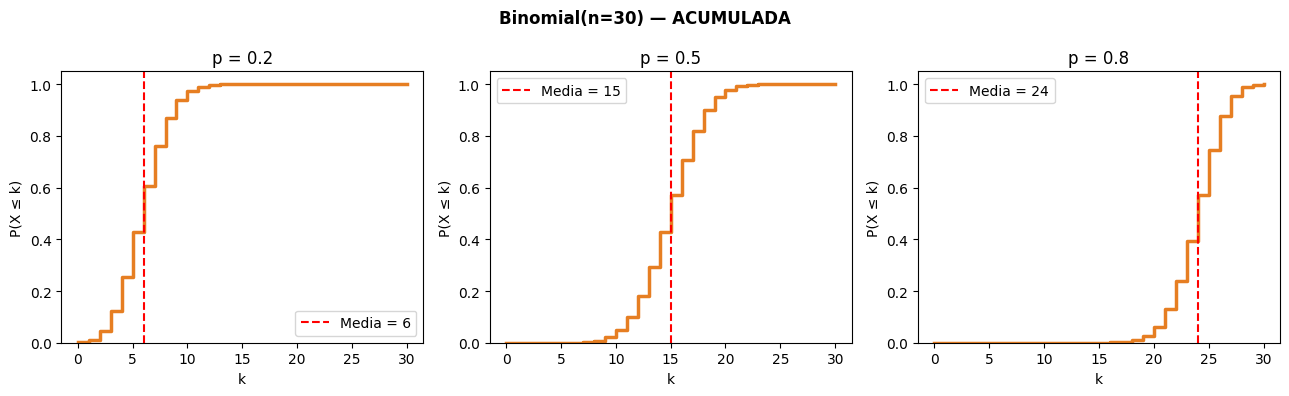

In [35]:
# Dibujo de las distribuciones y la acumulada junto con la media, que sale de hacer p*n
n = 30
k = np.arange(0, n + 1)
p_vals = [0.2, 0.5, 0.8] #Tasas de aprobación

# Primera figura: DENSIDAD
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Binomial(n=30) - DISTRIBUCION', fontweight='bold')

for ax, p_val in zip(axes, p_vals):
    probs = stats.binom.pmf(k, n, p_val) #DENSIDAD
    ax.bar(k, probs, color='#3498db', alpha=0.85, edgecolor='white')
    ax.axvline(n * p_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Media = {n*p_val:.0f}')
    ax.set_title(f'p = {p_val}')
    ax.set_xlabel('k')
    ax.set_ylabel('P(X = k)')
    ax.legend()

plt.tight_layout()
plt.show()

# Segunda figura: ACUMULADA
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Binomial(n=30) — ACUMULADA', fontweight='bold')

for ax, p_val in zip(axes, p_vals):
    acum = stats.binom.cdf(k, n, p_val) #ACUMULADA
    ax.step(k, acum, color='#e67e22', linewidth=2.5, where='post')
    ax.axvline(n * p_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Media = {n*p_val:.0f}')
    ax.set_title(f'p = {p_val}')
    ax.set_xlabel('k')
    ax.set_ylabel('P(X ≤ k)')
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()

###  Poisson — $X \sim \text{Po}(\lambda)$

Cantidad de eventos en un intervalo fijo. $\lambda$ es la tasa de ocurrencia (también su media y varianza).

$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$$

> **Ejemplo:** cantidad de colectivos que pasan por una parada en un rango de una hora

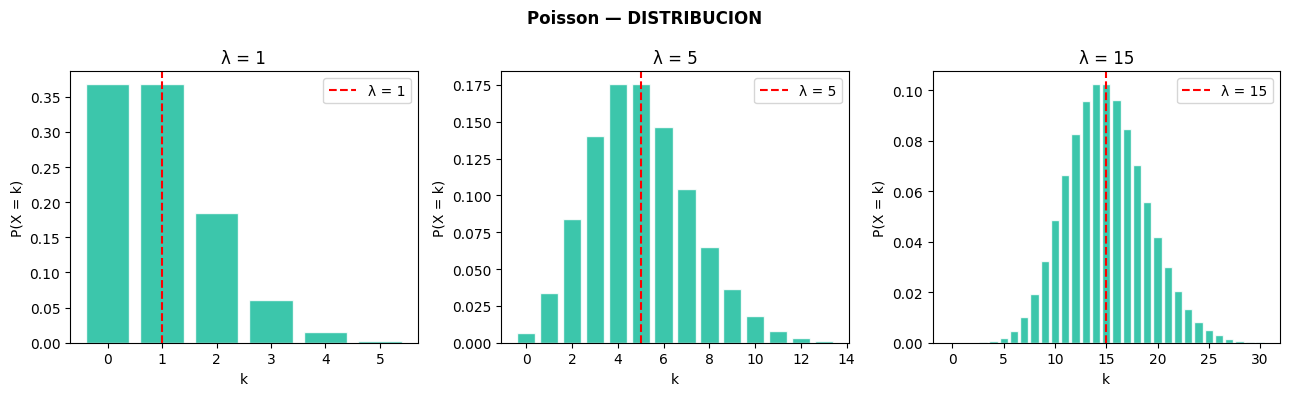

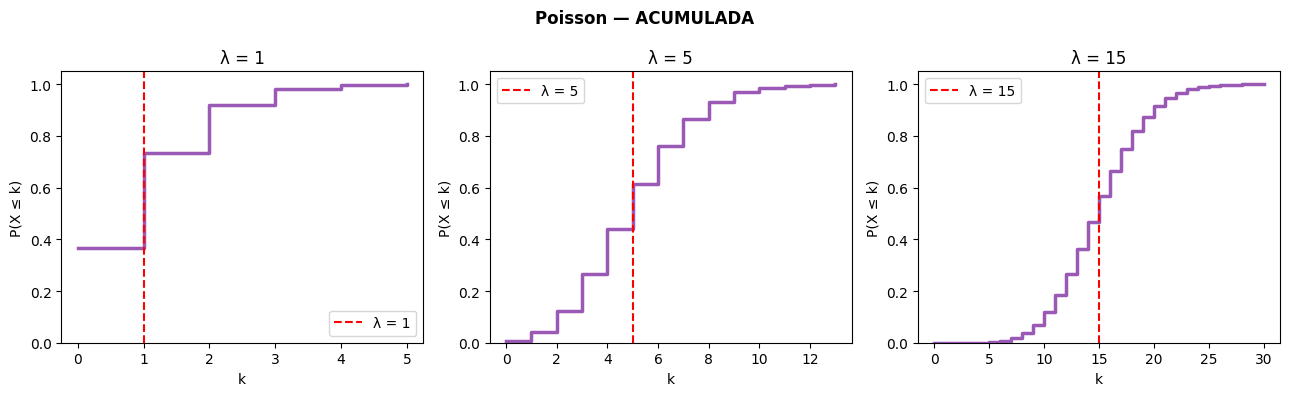

In [38]:
lam_vals = [1, 5, 15]

# Primera figura: DENSIDAD
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Poisson — DISTRIBUCION', fontweight='bold')

for ax, lam in zip(axes, lam_vals):
    k = np.arange(0, lam + int(4 * np.sqrt(lam)) + 1)
    probs = stats.poisson.pmf(k, lam) #Este es nuestro array de probabilidades
    ax.bar(k, probs, color='#1abc9c', alpha=0.85, edgecolor='white')
    ax.axvline(lam, color='red', linestyle='--', linewidth=1.5, label=f'λ = {lam}')
    ax.set_title(f'λ = {lam}')
    ax.set_xlabel('k')
    ax.set_ylabel('P(X = k)')
    ax.legend()

plt.tight_layout()
plt.show()

# Segunda figura: ACUMULADA
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Poisson — ACUMULADA', fontweight='bold')

for ax, lam in zip(axes, lam_vals):
    k = np.arange(0, lam + int(4 * np.sqrt(lam)) + 1)
    acum = stats.poisson.cdf(k, lam) # La acumulada
    ax.step(k, acum, color='#9b59b6', linewidth=2.5, where='post')
    ax.axvline(lam, color='red', linestyle='--', linewidth=1.5, label=f'λ = {lam}')
    ax.set_title(f'λ = {lam}')
    ax.set_xlabel('k')
    ax.set_ylabel('P(X ≤ k)')
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()

---
## Distribuciones Continuas

Para variables continuas no hay probabilidad puntual: la probabilidad de un intervalo se calcula como el área bajo la **función de densidad** $f(x)$.

### Exponencial — $X \sim \text{Exp}(\lambda)$

Modela tiempos de espera. Mayor $\lambda$ → más frecuente → esperas más cortas.

$$f_X(x) = \lambda e^{-\lambda x}, \quad x \geq 0 \qquad E(X) = \frac{1}{\lambda}$$

> **Ejemplo:** tiempo entre llegadas de clientes a un local. El $\lambda$ en este caso es la cantidad de clientes por unidad de tiempo.

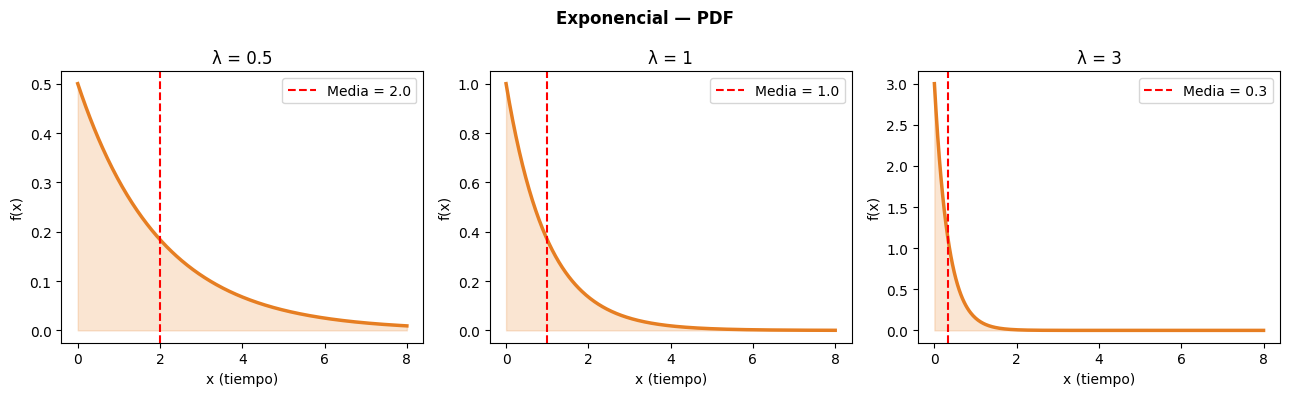

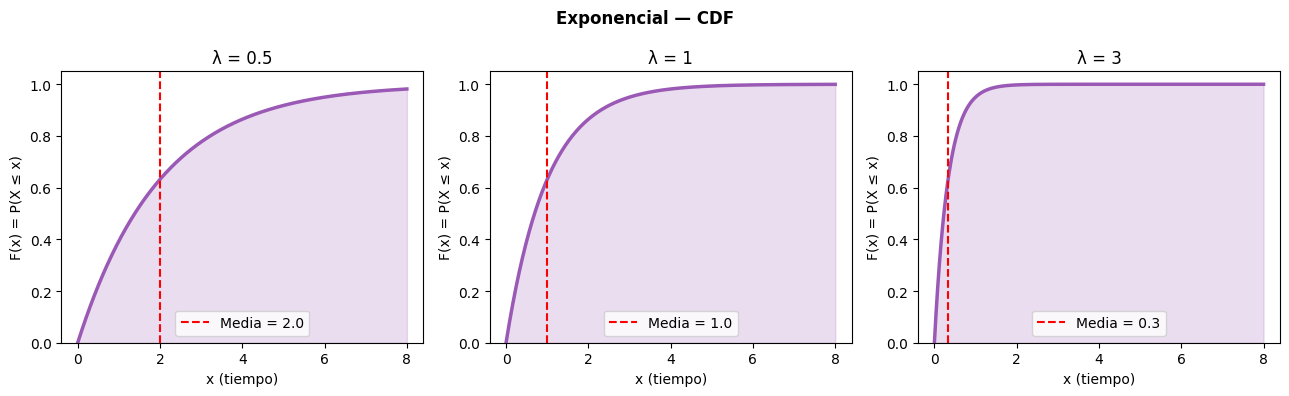

In [39]:
lam_vals = [0.5, 1, 3]
x = np.linspace(0, 8, 400)

# Primera figura: DENSIDAD
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Exponencial — PDF', fontweight='bold')

for ax, lam in zip(axes, lam_vals):
    y = stats.expon.pdf(x, scale=1/lam)
    ax.plot(x, y, color='#e67e22', linewidth=2.5)
    ax.fill_between(x, y, alpha=0.2, color='#e67e22')
    ax.axvline(1/lam, color='red', linestyle='--', linewidth=1.5,
               label=f'Media = {1/lam:.1f}')
    ax.set_title(f'λ = {lam}')
    ax.set_xlabel('x (tiempo)')
    ax.set_ylabel('f(x)')
    ax.legend()

plt.tight_layout()
plt.show()

# Segunda figura: ACUMULADA
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Exponencial — CDF', fontweight='bold')

for ax, lam in zip(axes, lam_vals):
    y = stats.expon.cdf(x, scale=1/lam)
    ax.plot(x, y, color='#9b59b6', linewidth=2.5)
    ax.fill_between(x, y, alpha=0.2, color='#9b59b6')
    ax.axvline(1/lam, color='red', linestyle='--', linewidth=1.5,
               label=f'Media = {1/lam:.1f}')
    ax.set_title(f'λ = {lam}')
    ax.set_xlabel('x (tiempo)')
    ax.set_ylabel('F(x) = P(X ≤ x)')
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()

### Normal — $X \sim \mathcal{N}(\mu, \sigma^2)$

La más importante en estadística. El TCL garantiza que la media muestral converge a ella.

$$f_X(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

In [40]:
# Simular alturas de personas (mu=170cm, sigma=10cm)
mu, sigma = 170, 10
alturas = np.random.normal(mu, sigma, size=500)
df_alturas = pd.DataFrame({'altura_cm': alturas})
print(df_alturas.describe().round(1))

       altura_cm
count      500.0
mean       170.1
std          9.8
min        139.8
25%        163.6
50%        170.0
75%        176.7
max        201.9


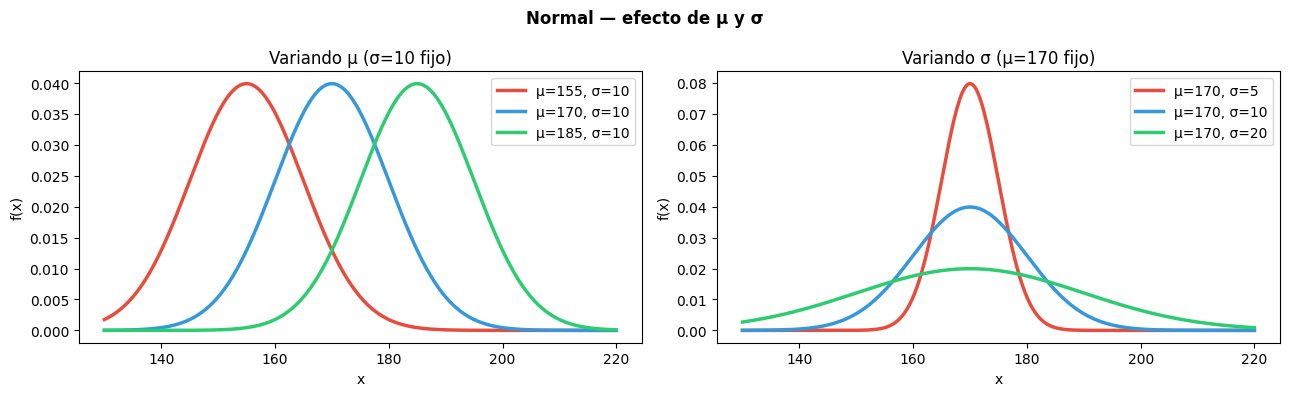

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Normal — efecto de μ y σ', fontweight='bold')

x = np.linspace(130, 220, 400)

# Efecto de mu
for mu_val, color in zip([155, 170, 185], ['#e74c3c', '#3498db', '#2ecc71']):
    axes[0].plot(x, stats.norm.pdf(x, mu_val, 10), color=color,
                 linewidth=2.5, label=f'μ={mu_val}, σ=10')
axes[0].set_title('Variando μ (σ=10 fijo)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()

# Efecto de sigma
for sigma_val, color in zip([5, 10, 20], ['#e74c3c', '#3498db', '#2ecc71']):
    axes[1].plot(x, stats.norm.pdf(x, 170, sigma_val), color=color,
                 linewidth=2.5, label=f'μ=170, σ={sigma_val}')
axes[1].set_title('Variando σ (μ=170 fijo)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Aplicación Teorema Central del Límite

Partimos de datos con distribución Exponencial y mostramos cómo la distribución de $\bar{X}$ se va pareciendo a una Normal a medida que $n$ crece.

Cada columna del DataFrame de abajo representa 10.000 repeticiones del experimento de tomar una muestra de tamaño $n$ y calcular su media.

In [53]:
M = 10_000   # repeticiones del experimento
lam = 1 #parámetro de la distribucion
ns = [1, 5, 30, 100] #tamaño de muestra

# Guardar las medias en un DataFrame: cada columna es un n
df_tcl = pd.DataFrame({
    f'n={n}': [np.mean(np.random.exponential(1/lam, n)) for _ in range(M)]
    for n in ns
})

print(df_tcl.describe().round(3))


             n=1        n=5       n=30      n=100
count  10000.000  10000.000  10000.000  10000.000
mean       1.000      1.004      0.998      0.999
std        0.995      0.447      0.180      0.099
min        0.000      0.107      0.424      0.688
25%        0.289      0.679      0.870      0.931
50%        0.704      0.935      0.989      0.997
75%        1.398      1.258      1.114      1.064
max        8.975      3.419      1.768      1.412


In [ ]:
df_tcl
# El dataframe nos entrega medias muestrales. 
# Las muestras en tamaño están dadas por el n y son el promedio de aleatoriamente dar un tiempo de espera en este caso

,n=1,n=5,n=30,n=100
0,1.886425,0.780709,0.912258,0.940744
1,0.459119,1.178548,0.924694,0.978662
2,1.055049,1.580315,1.160777,0.892433
3,2.061478,2.664711,0.907709,1.121429
4,1.446263,1.064609,1.271400,0.967778
...,...,...,...,...
9995,1.633451,1.127284,0.809482,1.021409
9996,0.212188,0.585529,1.090563,1.127409
9997,1.005382,0.805408,0.897779,0.989883
9998,0.352024,2.146579,0.876965,0.842402


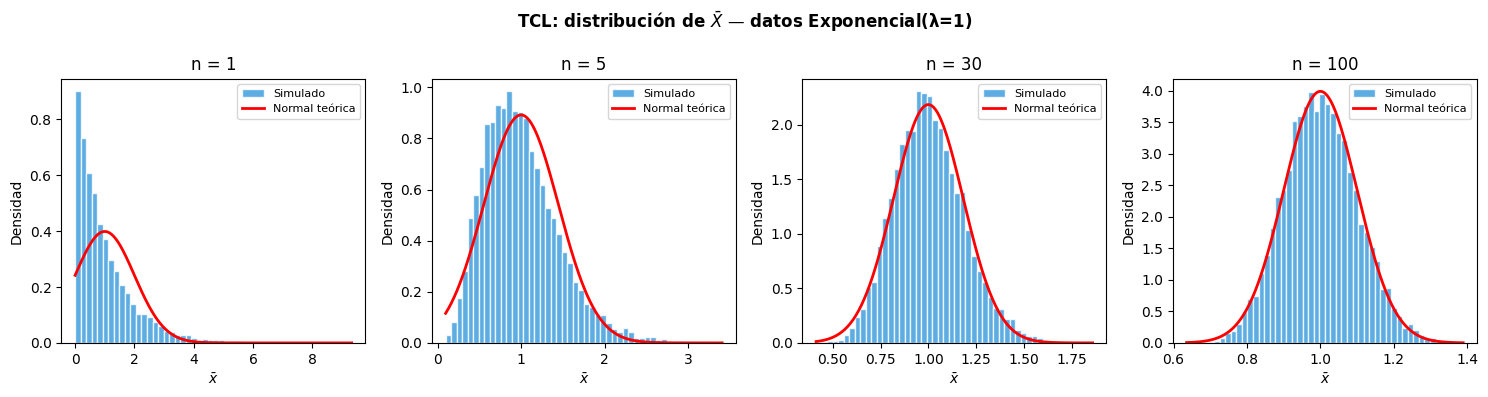

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle('TCL: distribución de $\\bar{X}$ — datos Exponencial(λ=1)', fontweight='bold')

for ax, n in zip(axes, ns):
    col = f'n={n}'
    medias = df_tcl[col]

    # Histograma de las medias simuladas
    ax.hist(medias, bins=50, density=True, color='#3498db',
            edgecolor='white', alpha=0.8, label='Simulado')

    # Normal teórica que predice el TCL
    mu_teo = 1 / lam #La media de la distribucion es la media muestral (LGN)
    sigma_teo = (1 / lam) / np.sqrt(n) #El desvío
    x = np.linspace(medias.min(), medias.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu_teo, sigma_teo),
            color='red', linewidth=2, label='Normal teórica')

    ax.set_title(f'n = {n}')
    ax.set_xlabel('$\\bar{x}$')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Referencias
- [Scipy Stats](https://docs.scipy.org/doc/scipy/reference/stats.html)